In [2]:
import pandas as pd
import sys
sys.path.append('/home/azureuser/cloudfiles/code/Users/manhductranvu/reeval-multi/mirt-official') 
from load_params import load_and_rotate

resmat = pd.read_pickle("../data/resmat.pkl")

theta, a, b = load_and_rotate(rotation=None)

# Step 1: Get the final theta tensor into a NumPy array
theta_abilities = theta
# Step 2: Create a labeled pandas DataFrame
# Use the model names from your original resmat for the index
model_names = resmat.index
factor_names = [f'F{i+1}' for i in range(theta.shape[1])]
ability_df = pd.DataFrame(theta_abilities, index=model_names, columns=factor_names)

--- Loading from Cache ---
Loaded cached theta shape: (183, 19)
Loaded cached a shape: (78712, 19)
Loaded cached b shape: (78712,)



In [3]:
import numpy as np
import pandas as pd

def compute_scalar_ability(theta_df, a_df, b_series, item_ids, v_unit=None, adjust_difficulty=True, return_v_unit=False):
	"""
	Compute a math-specific ability score from MIRT factors, discriminations, and difficulties.
	
	Args:
		theta_df (pd.DataFrame): Factor scores per test taker (rows = test takers, cols = factors).
		a_df (pd.DataFrame): Discrimination parameters (rows = items, cols = factors).
		b_series (pd.Series): Difficulty parameters (indexed same as a_df rows).
		item_ids (list): List of item IDs (subset of a_df rows) that are math items.
		adjust_difficulty (bool): Whether to weight discriminations by difficulty.
	
	Returns:
		pd.Series: Math ability scores for each test taker.
	"""
	if v_unit is None:
		# 1. Extract discrimination vectors for math items
		A_math = a_df.loc[item_ids].copy()
		b_math = b_series.loc[item_ids]

		# 2. Optionally adjust by difficulty
		if adjust_difficulty:
			weights = 1 / (1 + np.abs(b_math.values))
			A_math = A_math.multiply(weights, axis=0)

		# 3. Compute math direction vector in factor space
		v_unit = A_math.mean(axis=0).values  # vector of length = num_factors
		v_unit = v_unit / np.linalg.norm(v_unit)  # normalize for stability
		print("Mean unit vector: ", v_unit)
		if return_v_unit:
			return v_unit

	else: 
		print("Used pre-computed direction vector.", v_unit)

	# 4. Project each test taker's theta onto v_unit
	theta_matrix = theta_df.values  # shape (n_test_takers, n_factors)
	math_scores = theta_matrix.dot(v_unit)

	return pd.Series(math_scores, index=theta_df.index, name="ability")


In [4]:
conv_dataset = ['math', 'gsm']


models = resmat.index.to_list()
questions = resmat.columns.get_level_values('input.text').to_list()
items_mask = resmat.columns.get_level_values('scenario').isin(conv_dataset)

scenario_questions = resmat.columns[items_mask].get_level_values('input.text').to_list()

pd.DataFrame(scenario_questions, columns=['question']).to_pickle('../result/math_scenario_questions.pkl')

theta_df = pd.DataFrame(theta, index=models)

a_df = pd.DataFrame(a, index=questions)

b_series = pd.Series(b, index=questions)

In [5]:
import numpy as np
import pandas as pd

def orthogonalize_vector(vector_to_purify, reference_vector):
    """
    Purifies a vector by removing its projection onto a reference vector.
    This is a single step of the Gram-Schmidt process.

    Args:
        vector_to_purify (np.ndarray): The vector you want to purify (e.g., v_math).
        reference_vector (np.ndarray): The vector representing the component to remove (e.g., v_div).

    Returns:
        np.ndarray: The purified, orthogonal vector, normalized to unit length.
    """
    # Ensure vectors are normalized to unit length to start
    vector_to_purify = vector_to_purify / np.linalg.norm(vector_to_purify)
    reference_vector = reference_vector / np.linalg.norm(reference_vector)

    # 1. Calculate the projection of vector_to_purify onto reference_vector
    dot_product = np.dot(vector_to_purify, reference_vector)
    projection = dot_product * reference_vector
    
    # 2. Subtract the projection to get the orthogonal component
    purified_vector = vector_to_purify - projection
    
    # 3. Normalize the final vector to have a length of 1
    purified_vector_normalized = purified_vector / np.linalg.norm(purified_vector)
    
    return purified_vector_normalized

## Mean vector analysis

In [6]:
conv_dataset = ['math', 'gsm']


models = resmat.index.to_list()
questions = resmat.columns.get_level_values('input.text').to_list()
items_mask = resmat.columns.get_level_values('scenario').isin(conv_dataset)

scenario_questions = resmat.columns[items_mask].get_level_values('input.text').to_list()
inverse_mask = ~items_mask
inverse_questions = resmat.columns[inverse_mask].get_level_values('input.text').to_list()
 
v_unit = compute_scalar_ability(theta_df, a_df, b_series, inverse_questions, return_v_unit=True)
v_math_unit = compute_scalar_ability(theta_df, a_df, b_series, scenario_questions, return_v_unit=True)


# --- Main Execution ---

v_math_initial = v_math_unit
v_div_reference = v_unit

# --- Run the Orthogonalization ---
v_math_pure = orthogonalize_vector(v_math_initial, v_div_reference)

print("Purified 'Math' Vector (v_math_pure):")
print(np.round(v_math_pure, 4))

# --- Verification ---
# The dot product of the purified vector and the reference vector should be nearly zero.
final_correlation = np.dot(v_math_pure, v_div_reference / np.linalg.norm(v_div_reference))
print(f"\nCorrelation after Orthogonalization (Dot Product): {final_correlation:.4f}")

if np.isclose(final_correlation, 0):
    print("Verification successful: The new math vector is orthogonal to the divergent vector.")
else:
    print("Verification failed.")

Mean unit vector:  [ 0.18408574  0.10199574 -0.19005632  0.15659423 -0.11202672 -0.04533361
  0.10487782  0.32844433 -0.2575905  -0.28445843 -0.03283864  0.20346875
 -0.33114243 -0.5151285   0.0584776   0.07602055  0.15815003  0.2574735
  0.31035966]
Mean unit vector:  [-0.21494706 -0.22744916 -0.23566988 -0.1679211  -0.3850087  -0.2394518
  0.04993943  0.25944665 -0.39451882 -0.04396391 -0.01316161 -0.33871678
  0.30975133  0.06780565  0.26811373 -0.26613766  0.13065511 -0.04555357
 -0.08982014]
Purified 'Math' Vector (v_math_pure):
[-0.2122 -0.2259 -0.2386 -0.1656 -0.3868 -0.2402  0.0515  0.2645 -0.3985
 -0.0483 -0.0137 -0.3357  0.3048  0.06    0.269  -0.265   0.1331 -0.0416
 -0.0851]

Correlation after Orthogonalization (Dot Product): 0.0000
Verification successful: The new math vector is orthogonal to the divergent vector.


In [7]:
math_scores_pure= compute_scalar_ability(theta_df, a_df, b_series, scenario_questions, v_math_pure)
div_scores_pure= compute_scalar_ability(theta_df, a_df, b_series, inverse_questions, v_unit)
conv_benchmark_mean = resmat[resmat.columns[resmat.columns.get_level_values('scenario').isin(conv_dataset)]].mean(axis=1)

div_math_corr = math_scores_pure.corr(div_scores_pure, method='spearman')
print('div_corr', div_math_corr)

conv_math_corr = math_scores_pure.corr(conv_benchmark_mean, method='spearman')
print('conv_corr', conv_math_corr)

Used pre-computed direction vector. [-0.2121759  -0.22592627 -0.2385837  -0.16556206 -0.3867546  -0.24016796
  0.05153811  0.26446506 -0.3984767  -0.04828941 -0.01366189 -0.3356655
  0.30475757  0.05998956  0.26903284 -0.26501375  0.13307221 -0.04164824
 -0.08511668]
Used pre-computed direction vector. [ 0.18408574  0.10199574 -0.19005632  0.15659423 -0.11202672 -0.04533361
  0.10487782  0.32844433 -0.2575905  -0.28445843 -0.03283864  0.20346875
 -0.33114243 -0.5151285   0.0584776   0.07602055  0.15815003  0.2574735
  0.31035966]
div_corr 0.05946441299256695
conv_corr 0.9578550469115413


In [8]:
conv_dataset = ['air_bench_2024']

models = resmat.index.to_list()
questions = resmat.columns.get_level_values('input.text').to_list()
items_mask = resmat.columns.get_level_values('scenario').isin(conv_dataset)

scenario_questions = resmat.columns[items_mask].get_level_values('input.text').to_list()
inverse_mask = ~items_mask
inverse_questions = resmat.columns[inverse_mask].get_level_values('input.text').to_list()
 
v_unit = compute_scalar_ability(theta_df, a_df, b_series, inverse_questions, return_v_unit=True)
v_airbench_unit = compute_scalar_ability(theta_df, a_df, b_series, scenario_questions, return_v_unit=True)


# --- Main Execution ---

v_airbench_initial = v_airbench_unit
v_div_reference = v_unit

# --- Run the Orthogonalization ---
v_airbench_pure = orthogonalize_vector(v_airbench_initial, v_div_reference)

print("Purified Vector:")
print(np.round(v_airbench_pure, 4))

# --- Verification ---
# The dot product of the purified vector and the reference vector should be nearly zero.
final_correlation = np.dot(v_airbench_pure, v_div_reference / np.linalg.norm(v_div_reference))
print(f"\nCorrelation after Orthogonalization (Dot Product): {final_correlation:.4f}")

if np.isclose(final_correlation, 0, atol=1e-6):
    print("Verification successful: The new vector is orthogonal to the divergent vector.")
else:
    print("Verification failed.")

Mean unit vector:  [ 0.15788884  0.12192029 -0.20424938  0.14769147 -0.08909655  0.00674207
  0.13001913  0.38275072 -0.3342275  -0.27393126  0.03548491  0.25131562
 -0.28736213 -0.4951297   0.04810696  0.04254235  0.16937524  0.20083156
  0.27064428]
Mean unit vector:  [ 8.7650202e-02 -1.9348134e-01 -4.5048916e-03  3.0354402e-04
 -2.7384856e-01 -3.9389920e-01 -1.2806861e-01 -2.2029307e-01
  3.0856737e-01 -8.8170439e-02 -4.1135219e-01 -3.9413470e-01
 -1.6451129e-01 -1.1405341e-01  1.5675986e-01  1.0914784e-01
 -1.5494092e-02  3.2985809e-01  2.1595275e-01]
Purified Vector:
[ 0.0945 -0.1885 -0.0132  0.0066 -0.2779 -0.394  -0.1226 -0.2042  0.2946
 -0.0999 -0.4102 -0.3838 -0.1769 -0.1353  0.159   0.1111 -0.0083  0.3387
  0.2277]

Correlation after Orthogonalization (Dot Product): 0.0000
Verification successful: The new vector is orthogonal to the divergent vector.


In [9]:
civil_scores_pure= compute_scalar_ability(theta_df, a_df, b_series, scenario_questions, v_airbench_pure)
div_scores_pure= compute_scalar_ability(theta_df, a_df, b_series, inverse_questions, v_unit)
conv_benchmark_mean = resmat[resmat.columns[resmat.columns.get_level_values('scenario').isin(conv_dataset)]].mean(axis=1)

div_airbench_corr = civil_scores_pure.corr(div_scores_pure, method='spearman')
print('div_corr', div_airbench_corr)

conv_airbench_corr = civil_scores_pure.corr(conv_benchmark_mean, method='spearman')
print('conv_corr', conv_airbench_corr)

Used pre-computed direction vector. [ 0.09446862 -0.18845399 -0.01322626  0.00660722 -0.2779005  -0.39397007
 -0.12263606 -0.20415801  0.29458362 -0.09994196 -0.41021222 -0.3837675
 -0.17692555 -0.13528915  0.15895575  0.1110629  -0.00827934  0.3387298
  0.22770032]
Used pre-computed direction vector. [ 0.15788884  0.12192029 -0.20424938  0.14769147 -0.08909655  0.00674207
  0.13001913  0.38275072 -0.3342275  -0.27393126  0.03548491  0.25131562
 -0.28736213 -0.4951297   0.04810696  0.04254235  0.16937524  0.20083156
  0.27064428]
div_corr -0.0762964761539245
conv_corr 0.9885017421602788


/var/folders/gy/d7p0zrqx7l3f7dwplj0g_b040000gn/T/ipykernel_91129/1092643341.py:31: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


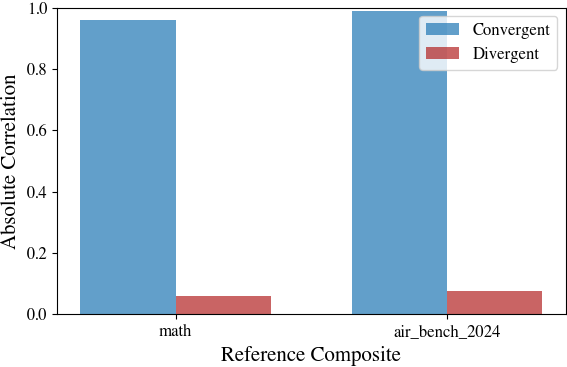

In [10]:
sys.path.append('..') 
import style
import matplotlib.pyplot as plt
plt.rcParams.update(style.rcparams)
import numpy as np

# Calculate correlations for PC1, PC2, PC3
pcs = [f'PC{i+1}' for i in range(2)]
conv_corrs = np.absolute([conv_math_corr, conv_airbench_corr])
div_corrs = np.absolute([div_math_corr, div_airbench_corr])

# Create the two-bar histogram
x = np.arange(len(pcs))  # PC positions
width = 0.35  # Width of the bars

fig, ax = plt.subplots(figsize=(6, 4))
bars1 = ax.bar(x - width/2, conv_corrs, width, label='Convergent', color='C0', alpha=0.7)
bars2 = ax.bar(x + width/2, div_corrs, width, label='Divergent', color='firebrick', alpha=0.7)

# Add horizontal dashed lines
# ax.axhline(y=abs(sum(conv_corrs) / len(conv_corrs)), color='C0', linestyle='--', alpha=0.7, label='Mean Conv', linewidth=0.8)
# ax.axhline(y=abs(sum(div_corrs) / len(div_corrs)), color='firebrick', linestyle='--', alpha=0.7, label='Mean Div', linewidth=0.8)

# Customize the plot
ax.set_ylabel('Absolute Correlation')
ax.set_xlabel('Reference Composite')
ax.set_xticks(x)
ax.set_xticklabels(['math', 'air_bench_2024'])
ax.set_ylim(0, 1)
ax.legend()
plt.tight_layout()
plt.savefig(f'../result/selective_scale_correlations.pdf')
plt.show()

# Verification with Eigenvectors

In [11]:
import pandas as pd
import numpy as np

def get_reference_composite_eigenvector(a_df: pd.DataFrame) -> np.ndarray:
    """
    Calculates the eigenvector for the reference composite from a matrix of 
    multidimensional discrimination parameters.

    This vector corresponds to the largest eigenvalue of the a'a matrix and 
    represents the direction of the dominant unidimensional scale in the 
    multidimensional space.

    Args:
        a_df: A pandas DataFrame with shape (n_items, n_dimensions) 
              containing the 'a' parameters.

    Returns:
        A NumPy array representing the eigenvector of the reference composite.
    """
    # Convert the DataFrame to a NumPy array for matrix operations
    a_matrix = a_df.to_numpy()
    
    # Calculate the a-transpose-a matrix (a'a)
    a_t_a = a_matrix.T @ a_matrix
    
    # Calculate the eigenvalues and eigenvectors of the a'a matrix
    eigenvalues, eigenvectors = np.linalg.eig(a_t_a)
    
    # Find the index of the largest eigenvalue
    max_eigenvalue_index = np.argmax(eigenvalues)
    
    # Select the corresponding eigenvector
    reference_composite_vector = eigenvectors[:, max_eigenvalue_index]
    
    return reference_composite_vector

In [12]:
conv_dataset = ['math', 'gsm']

models = resmat.index.to_list()
questions = resmat.columns.get_level_values('input.text').to_list()
items_mask = resmat.columns.get_level_values('scenario').isin(conv_dataset)

scenario_questions = resmat.columns[items_mask].get_level_values('input.text').to_list()
inverse_mask = ~items_mask
inverse_questions = resmat.columns[inverse_mask].get_level_values('input.text').to_list()
 
v_unit = compute_scalar_ability(theta_df, a_df, b_series, inverse_questions, return_v_unit=True)
v_math_unit = get_reference_composite_eigenvector(a_df.loc[scenario_questions])

# --- Main Execution ---

v_math_initial = v_math_unit
v_div_reference = v_unit

# --- Run the Orthogonalization ---
v_math_pure = orthogonalize_vector(v_math_initial, v_div_reference)

print("Purified 'Math' Vector (v_math_pure):")
print(np.round(v_math_pure, 4))

# --- Verification ---
# The dot product of the purified vector and the reference vector should be nearly zero.
final_correlation = np.dot(v_math_pure, v_div_reference / np.linalg.norm(v_div_reference))
print(f"\nCorrelation after Orthogonalization (Dot Product): {final_correlation:.4f}")

if np.isclose(final_correlation, 0):
    print("Verification successful: The new math vector is orthogonal to the divergent vector.")
else:
    print("Verification failed.")

Mean unit vector:  [ 0.18408574  0.10199574 -0.19005632  0.15659423 -0.11202672 -0.04533361
  0.10487782  0.32844433 -0.2575905  -0.28445843 -0.03283864  0.20346875
 -0.33114243 -0.5151285   0.0584776   0.07602055  0.15815003  0.2574735
  0.31035966]
Purified 'Math' Vector (v_math_pure):
[-0.2222 -0.2373 -0.2402 -0.1697 -0.3785 -0.2423  0.0652  0.267  -0.3984
 -0.0502 -0.0166 -0.3251  0.3007  0.0642  0.2604 -0.2678  0.1399 -0.0375
 -0.0898]

Correlation after Orthogonalization (Dot Product): 0.0000
Verification successful: The new math vector is orthogonal to the divergent vector.


In [13]:
math_scores_pure= compute_scalar_ability(theta_df, a_df, b_series, scenario_questions, v_math_pure)
div_scores_pure= compute_scalar_ability(theta_df, a_df, b_series, inverse_questions, v_unit)
conv_benchmark_mean = resmat[resmat.columns[resmat.columns.get_level_values('scenario').isin(conv_dataset)]].mean(axis=1)

div_math_corr = math_scores_pure.corr(div_scores_pure, method='spearman')
print('div_corr', div_math_corr)

conv_math_corr = math_scores_pure.corr(conv_benchmark_mean, method='spearman')
print('conv_corr', conv_math_corr)

Used pre-computed direction vector. [-0.22217683 -0.23732743 -0.24023862 -0.1697346  -0.37846613 -0.24225266
  0.06519122  0.26698127 -0.39838114 -0.05022392 -0.01661013 -0.32513592
  0.30071217  0.06421725  0.2603656  -0.2678348   0.1399193  -0.03747842
 -0.08976768]
Used pre-computed direction vector. [ 0.18408574  0.10199574 -0.19005632  0.15659423 -0.11202672 -0.04533361
  0.10487782  0.32844433 -0.2575905  -0.28445843 -0.03283864  0.20346875
 -0.33114243 -0.5151285   0.0584776   0.07602055  0.15815003  0.2574735
  0.31035966]
div_corr 0.06141862414136114
conv_corr 0.9577276365666086


In [14]:
conv_dataset = ['air_bench_2024']


models = resmat.index.to_list()
questions = resmat.columns.get_level_values('input.text').to_list()
items_mask = resmat.columns.get_level_values('scenario').isin(conv_dataset)

scenario_questions = resmat.columns[items_mask].get_level_values('input.text').to_list()
inverse_mask = ~items_mask
inverse_questions = resmat.columns[inverse_mask].get_level_values('input.text').to_list()
 
v_unit = compute_scalar_ability(theta_df, a_df, b_series, inverse_questions, return_v_unit=True)
v_airbench_unit = get_reference_composite_eigenvector(a_df.loc[scenario_questions])


# --- Main Execution ---

v_airbench_initial = v_airbench_unit
v_div_reference = v_unit

# --- Run the Orthogonalization ---
v_airbench_pure = orthogonalize_vector(v_airbench_initial, v_div_reference)

print("Purified Vector:")
print(np.round(v_airbench_pure, 4))

# --- Verification ---
# The dot product of the purified vector and the reference vector should be nearly zero.
final_correlation = np.dot(v_airbench_pure, v_div_reference / np.linalg.norm(v_div_reference))
print(f"\nCorrelation after Orthogonalization (Dot Product): {final_correlation:.4f}")

if np.isclose(final_correlation, 0, atol=1e-6):
    print("Verification successful: The new vector is orthogonal to the divergent vector.")
else:
    print("Verification failed.")

Mean unit vector:  [ 0.15788884  0.12192029 -0.20424938  0.14769147 -0.08909655  0.00674207
  0.13001913  0.38275072 -0.3342275  -0.27393126  0.03548491  0.25131562
 -0.28736213 -0.4951297   0.04810696  0.04254235  0.16937524  0.20083156
  0.27064428]
Purified Vector:
[ 8.350e-02 -1.922e-01 -2.760e-02  2.950e-02 -2.865e-01 -3.835e-01
 -1.049e-01 -2.040e-01  2.795e-01 -7.910e-02 -4.078e-01 -3.929e-01
 -1.761e-01 -1.203e-01  1.855e-01  1.311e-01  3.000e-04  3.516e-01
  2.166e-01]

Correlation after Orthogonalization (Dot Product): 0.0000
Verification successful: The new vector is orthogonal to the divergent vector.


In [15]:
conv_scores_pure= compute_scalar_ability(theta_df, a_df, b_series, scenario_questions, v_airbench_pure)
div_scores_pure= compute_scalar_ability(theta_df, a_df, b_series, inverse_questions, v_unit)
conv_benchmark_mean = resmat[resmat.columns[resmat.columns.get_level_values('scenario').isin(conv_dataset)]].mean(axis=1)

div_airbench_corr = conv_scores_pure.corr(div_scores_pure, method='spearman')
print('div_corr', div_airbench_corr)

conv_airbench_corr = conv_scores_pure.corr(conv_benchmark_mean, method='spearman')
print('conv_corr', conv_airbench_corr)

Used pre-computed direction vector. [ 8.3472341e-02 -1.9222133e-01 -2.7564226e-02  2.9497756e-02
 -2.8652298e-01 -3.8351992e-01 -1.0490729e-01 -2.0395660e-01
  2.7948627e-01 -7.9143204e-02 -4.0780070e-01 -3.9288455e-01
 -1.7605518e-01 -1.2034319e-01  1.8554886e-01  1.3114275e-01
  3.3247721e-04  3.5156754e-01  2.1662463e-01]
Used pre-computed direction vector. [ 0.15788884  0.12192029 -0.20424938  0.14769147 -0.08909655  0.00674207
  0.13001913  0.38275072 -0.3342275  -0.27393126  0.03548491  0.25131562
 -0.28736213 -0.4951297   0.04810696  0.04254235  0.16937524  0.20083156
  0.27064428]
div_corr -0.07372937112780306
conv_corr 0.9885017421602788


/var/folders/gy/d7p0zrqx7l3f7dwplj0g_b040000gn/T/ipykernel_91129/271086658.py:26: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


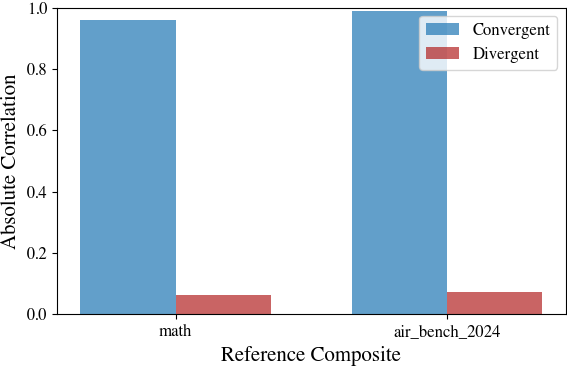

In [16]:
sys.path.append('..') 
import style
import matplotlib.pyplot as plt
plt.rcParams.update(style.rcparams)
import numpy as np

pcs = [f'PC{i+1}' for i in range(2)]
conv_corrs = np.absolute([conv_math_corr, conv_airbench_corr])
div_corrs = np.absolute([div_math_corr, div_airbench_corr])

# Create the two-bar histogram
x = np.arange(len(pcs))  # PC positions
width = 0.35  # Width of the bars

fig, ax = plt.subplots(figsize=(6, 4))
bars1 = ax.bar(x - width/2, conv_corrs, width, label='Convergent', color='C0', alpha=0.7)
bars2 = ax.bar(x + width/2, div_corrs, width, label='Divergent', color='firebrick', alpha=0.7)

# Customize the plot
ax.set_ylabel('Absolute Correlation')
ax.set_xlabel('Reference Composite')
ax.set_xticks(x)
ax.set_xticklabels(['math', 'air_bench_2024'])
ax.set_ylim(0, 1)
ax.legend()
plt.tight_layout()
plt.savefig(f'../result/selective_scale_correlations.pdf')
plt.show()

In [17]:
score_math_pure = compute_scalar_ability(theta_df, a_df, b_series, scenario_questions, v_math_pure)
score_airbench_pure = compute_scalar_ability(theta_df, a_df, b_series, scenario_questions, v_airbench_pure)

score_math_pure.corr(score_airbench_pure, method='spearman')

Used pre-computed direction vector. [-0.22217683 -0.23732743 -0.24023862 -0.1697346  -0.37846613 -0.24225266
  0.06519122  0.26698127 -0.39838114 -0.05022392 -0.01661013 -0.32513592
  0.30071217  0.06421725  0.2603656  -0.2678348   0.1399193  -0.03747842
 -0.08976768]
Used pre-computed direction vector. [ 8.3472341e-02 -1.9222133e-01 -2.7564226e-02  2.9497756e-02
 -2.8652298e-01 -3.8351992e-01 -1.0490729e-01 -2.0395660e-01
  2.7948627e-01 -7.9143204e-02 -4.0780070e-01 -3.9288455e-01
 -1.7605518e-01 -1.2034319e-01  1.8554886e-01  1.3114275e-01
  3.3247721e-04  3.5156754e-01  2.1662463e-01]


np.float64(0.10916168649597018)

In [18]:
mean_math_pure = score_math_pure.mean()
mean_airbench_pure = score_airbench_pure.mean()

v1 = v_math_pure
v2 = v_airbench_pure
mean_v1 = mean_math_pure
mean_v2 = mean_airbench_pure

a = 0.5

p = theta @ (a*v1 + (1-a)*v2) - (a * mean_v1 + (1-a) * mean_v2)

In [19]:
# Get mean scores and find common indices (models that have non-NaN values for both)
common_indices = resmat[resmat.columns[resmat.columns.get_level_values('scenario').isin(['math', 'gsm', 'air_bench_2024'])]].dropna().index.to_list()
print(len(common_indices))
print(common_indices)
# count each company in common_indices
company_counts = {}
for model in common_indices:
    company = model.split('/')[0]
    if company not in company_counts:
        company_counts[company] = 0
    company_counts[company] += 1
print(company_counts)

26
['mistralai/mistral-7b-instruct-v0.3', 'meta/llama-3.1-8b-instruct-turbo', 'cohere/command-r', 'google/gemini-1.0-pro-002', 'cohere/command-r-plus', 'databricks/dbrx-instruct', 'openai/gpt-3.5-turbo-0613', 'deepseek-ai/deepseek-llm-67b-chat', 'mistralai/mistral-large-2407', 'google/gemini-1.5-flash-002', 'anthropic/claude-3-haiku-20240307', 'openai/gpt-4o-mini-2024-07-18', 'meta/llama-3.1-70b-instruct-turbo', 'writer/palmyra-x-004', 'anthropic/claude-3-sonnet-20240229', 'deepseek-ai/deepseek-v3', 'openai/gpt-4o-2024-05-13', 'qwen/qwen2-72b-instruct', 'meta/llama-3.1-405b-instruct-turbo', 'openai/gpt-4-turbo-2024-04-09', 'openai/gpt-4-0613', 'openai/gpt-4o-2024-08-06', 'google/gemini-1.5-pro-002', 'anthropic/claude-3-opus-20240229', 'anthropic/claude-3-5-sonnet-20240620', 'anthropic/claude-3-5-sonnet-20241022']
{'mistralai': 2, 'meta': 3, 'cohere': 2, 'google': 3, 'databricks': 1, 'openai': 6, 'deepseek-ai': 2, 'anthropic': 5, 'writer': 1, 'qwen': 1}


In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Create meaningful, sorted model names for the example
model_names = theta_df.index

# --- Interpolation and Identification ---
# Define 'a' to increment by 0.05
a_values = np.arange(0, 1.01, 0.05)

results = []
# Loop through each value of 'a'
for a in a_values:
    # Your interpolation formula to get the p vector
    p = theta @ (a * v_math_pure + (1 - a) * (v_airbench_pure)) - (a * mean_math_pure + (1 - a) * mean_airbench_pure)
    
    # Find the index of the largest value in the p vector
    prominent_idx = np.argmax(p)
    
    # Get the name of the model at that index
    prominent_name = theta_df.index[prominent_idx]
    
    # Store our findings
    results.append({'a': a, 'index': prominent_idx, 'name': prominent_name})

# --- Option A: Print the results as text ---
print("Most Prominent Model at Each Step of 'a':")
for res in results:
    print(f"a = {res['a']:.2f}  =>  {res['name']}")

Most Prominent Model at Each Step of 'a':
a = 0.00  =>  anthropic/claude-3-5-sonnet-20241022
a = 0.05  =>  anthropic/claude-3-5-sonnet-20241022
a = 0.10  =>  anthropic/claude-3-5-sonnet-20241022
a = 0.15  =>  anthropic/claude-3-5-sonnet-20241022
a = 0.20  =>  anthropic/claude-3-5-sonnet-20241022
a = 0.25  =>  anthropic/claude-3-5-sonnet-20241022
a = 0.30  =>  anthropic/claude-3-5-sonnet-20241022
a = 0.35  =>  anthropic/claude-3-5-sonnet-20241022
a = 0.40  =>  anthropic/claude-3-5-sonnet-20241022
a = 0.45  =>  anthropic/claude-3-5-sonnet-20241022
a = 0.50  =>  anthropic/claude-3-5-sonnet-20241022
a = 0.55  =>  anthropic/claude-3-5-sonnet-20241022
a = 0.60  =>  anthropic/claude-3-5-sonnet-20241022
a = 0.65  =>  anthropic/claude-3-5-sonnet-20241022
a = 0.70  =>  anthropic/claude-3-5-sonnet-20241022
a = 0.75  =>  anthropic/claude-3-5-sonnet-20241022
a = 0.80  =>  meta/llama-3.1-405b-instruct-turbo
a = 0.85  =>  meta/llama-3.1-405b-instruct-turbo
a = 0.90  =>  meta/llama-3.1-405b-instruct-t

In [21]:
import numpy as np
import pandas as pd

# Assume theta_df and other variables are already defined
# For example:
p_dim = 183
# --- Interpolation and Identification ---
# Define 'a' to increment by 0.05
a_values = np.arange(0, 1.01, 0.5)

top_results_per_a = []
# Loop through each value of 'a'
for a in a_values:
    # Your interpolation formula to get the p vector
    p = theta @ (a * v_math_pure + (1 - a) * (v_airbench_pure)) - (a * mean_math_pure + (1 - a) * mean_airbench_pure)
    
    # --- MODIFICATION: Find the indices of the top 10 largest values ---
    # np.argsort() returns indices that would sort 'p' in ascending order.
    # [::-1] reverses the array to get descending order (largest first).
    # [:10] selects the first 10 indices from the sorted list.
    top_10_indices = np.argsort(p)[::-1][:10]
    
    # Get the names and p-values for these top 10 models
    top_10_names = theta_df.index[top_10_indices]
    top_10_values = p[top_10_indices]
    
    # Store the findings for this 'a' value
    top_results_per_a.append({
        'a': a,
        'names': top_10_names,
        'values': top_10_values
    })

# --- MODIFICATION: Print the formatted results ---
print("Top 10 Prominent Models at Each Step of 'a':\n")
for res in top_results_per_a:
    # Print a header for each 'a' increment
    print(f"----- a = {res['a']:.2f} -----")
    # Loop through the top 10 models and print them as a ranked list
    for i in range(10):
        model_name = res['names'][i]
        model_value = res['values'][i]
        # Print rank, name, and prominence score
        print(f"  {i+1:2d}. {model_name:<20} (Score: {model_value:.4f})")
    print("-" * 35) # Separator for readability

Top 10 Prominent Models at Each Step of 'a':

----- a = 0.00 -----
   1. anthropic/claude-3-5-sonnet-20241022 (Score: 4.4421)
   2. anthropic/claude-3-5-sonnet-20240620 (Score: 3.8571)
   3. anthropic/claude-3-opus-20240229 (Score: 3.5709)
   4. anthropic/claude-3-sonnet-20240229 (Score: 3.0720)
   5. google/gemini-1.5-pro-001-safety-block-none (Score: 2.9036)
   6. google/gemini-1.5-flash-001-safety-block-none (Score: 2.7190)
   7. openai/o1-2024-12-17 (Score: 2.3195)
   8. anthropic/claude-3-haiku-20240307 (Score: 2.2461)
   9. openai/o3-mini-2025-01-31 (Score: 1.9773)
  10. openai/gpt-4-turbo-2024-04-09 (Score: 1.9435)
-----------------------------------
----- a = 0.50 -----
   1. anthropic/claude-3-5-sonnet-20241022 (Score: 3.3072)
   2. anthropic/claude-3-5-sonnet-20240620 (Score: 3.0408)
   3. anthropic/claude-3-opus-20240229 (Score: 2.8316)
   4. openai/gpt-4-turbo-2024-04-09 (Score: 2.1269)
   5. openai/gpt-4o-2024-08-06 (Score: 1.9931)
   6. anthropic/claude-3-sonnet-20240229 

/var/folders/gy/d7p0zrqx7l3f7dwplj0g_b040000gn/T/ipykernel_91129/4078649214.py:112: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


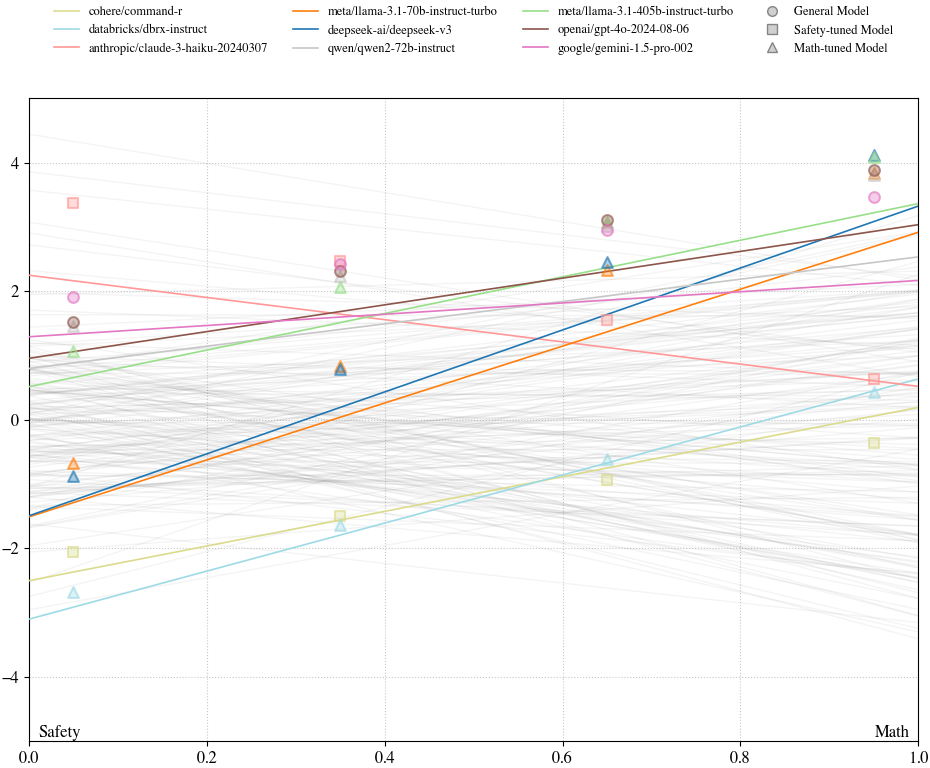

In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from sklearn.preprocessing import MinMaxScaler
from matplotlib.lines import Line2D

# --- EDITED: Added your classification dictionary ---
model_classification = {
    'deepseek-ai/deepseek-v3': 'math',
    'meta/llama-3.1-70b-instruct-turbo': 'math',
    'meta/llama-3.1-405b-instruct-turbo': 'math',
    'anthropic/claude-3-haiku-20240307': 'safety',
    'openai/gpt-4o-2024-08-06': 'general',
    'google/gemini-1.5-pro-002': 'general',
    'qwen/qwen2-72b-instruct': 'math',
    'cohere/command-r': 'safety',
    'databricks/dbrx-instruct': 'math'
}

models_to_highlight = model_classification.keys()


# In your text labels, "Safety" corresponds to the airbench vector
avg_math_acc = resmat[resmat.columns[resmat.columns.get_level_values('scenario').isin(['math', 'gsm'])]].mean(axis=1)
avg_safety_acc = resmat[resmat.columns[resmat.columns.get_level_values('scenario').isin(['air_bench_2024'])]].mean(axis=1)

# --- 2. Calculate and Scale Data ---
a_values = np.linspace(0, 1, 50)
p_matrix = np.zeros((p_dim, len(a_values)))
for i, model_theta in enumerate(theta):
    for j, a in enumerate(a_values):
        p = model_theta @ (a * v_math_pure + (1 - a) * v_airbench_pure) - (a * mean_math_pure + (1 - a) * mean_airbench_pure)
        p_matrix[i, j] = p

scaler = MinMaxScaler(feature_range=(-5, 5))
scaler.fit([[0], [1]])
def scale_accuracy(accuracy):
    return scaler.transform(np.array(accuracy).reshape(-1, 1)).flatten() if np.ndim(accuracy) else scaler.transform([[accuracy]])[0, 0]

# --- 3. Create the Plot ---
fig, ax = plt.subplots(figsize=(10, 8))

highlight_cmap = plt.get_cmap('tab20')
num_highlight = len(models_to_highlight)
highlight_colors = [highlight_cmap(i / max(num_highlight - 1, 1)) for i in range(num_highlight)]
highlight_color_map = dict(zip(models_to_highlight, highlight_colors))

for i in range(p_matrix.shape[0]):
    model_name = theta_df.index[i]
    if model_name in models_to_highlight:
        color = highlight_color_map[model_name]
        ax.plot(a_values, p_matrix[i, :], linewidth=1.2, alpha=1.0, label=model_name, color=color, zorder=10)
        
        math_acc = avg_math_acc.get(model_name, 0)
        safety_acc = avg_safety_acc.get(model_name, 0)
        
        scaled_math = scale_accuracy(math_acc)
        scaled_safety = scale_accuracy(safety_acc)

        x_dots = np.linspace(0.05, 0.95, 4)
        
        # --- EDITED: Corrected formula to match axes (Safety on left, Math on right) ---
        y_dots = (1 - x_dots) * scaled_safety + x_dots * scaled_math
        
        # --- EDITED: Determine marker shape based on classification ---
        model_type = model_classification.get(model_name)
        if model_type == 'math':
            marker_shape = '^'
        elif model_type == 'safety':
            marker_shape = 's'
        elif model_type == 'general':
            marker_shape = 'o'

        face_color = (*color[:3], 0.35)
        edge_color = (*color[:3], 0.65)
        
        ax.scatter(x_dots, y_dots, 
                   facecolor=face_color,
                   edgecolor=edge_color,
                   s=60,
                   linewidths=1.5,
                   marker=marker_shape,  # Apply the chosen marker shape
                   zorder=11)
    else:
        ax.plot(a_values, p_matrix[i, :], color='gray', alpha=0.085, lw=1)

# --- Inside your plotting code, before plt.show() ---

# 1. Get the handles and labels from your existing plot
handles, labels = ax.get_legend_handles_labels()

# 2. Create new, custom handles for the shapes
shape_handles = [
    Line2D([0], [0], marker='o', markerfacecolor='#44444440', markeredgecolor='#44444499', label='General Model',
           linestyle='None', markersize=7),
    Line2D([0], [0], marker='s', markerfacecolor='#44444440', markeredgecolor='#44444499', label='Safety-tuned Model',
           linestyle='None', markersize=7),
    Line2D([0], [0], marker='^', markerfacecolor='#44444440', markeredgecolor='#44444499', label='Math-tuned Model',
           linestyle='None', markersize=7)
]

ax.legend(handles=handles + shape_handles,  loc='lower center', bbox_to_anchor=(0.5, 1.05), ncol=4, fontsize=9, frameon=False)

# --- 4. Format the Plot ---
ax.set_xlim(0, 1)
ax.set_ylim(-5, 5)
ax.grid(True, linestyle=':', alpha=0.7)
ax.text(0.01, ax.get_ylim()[0], 'Safety', va='bottom') # Label for a=0
ax.text(0.99, ax.get_ylim()[0], 'Math', ha='right', va='bottom') # Label for a=1

fig.tight_layout()
plt.savefig(f'../result/selective-scale-accuracy.pdf', bbox_inches='tight')
plt.show()

In [23]:
# --- 5. Calculate and Print Sorted Performance Difference ---
# This code block goes after your p_matrix has been calculated.

# Get the performance scores at a=0 (first column) and a=1 (last column)
p_at_0 = p_matrix[:, 0]
p_at_1 = p_matrix[:, -1]

# Calculate the difference: p(a=1) - p(a=0)
performance_diff = p_at_1 - p_at_0

# Create a new DataFrame to hold the results for easy sorting
results_df = pd.DataFrame({
    'Model': theta_df.index,
    'Performance Difference (Math - air_bench_2024)': performance_diff
})

# Sort the DataFrame by the difference in descending order
sorted_results = results_df.sort_values(by='Performance Difference (Math - air_bench_2024)', ascending=False)

# Print the full sorted list
print("="*80)
print("Models Sorted by Performance Difference (Math vs. air_bench_2024)")
print("A large positive score indicates a 'Math Specialist'.")
print("A large negative score indicates a 'air_bench_2024 Specialist'.")
print("="*80)

# Filter the DataFrame to keep only models that are in the common_indices list
common_sorted_df = sorted_results[sorted_results['Model'].isin(common_indices)]

# Print the resulting DataFrame
print(common_sorted_df.to_string())

Models Sorted by Performance Difference (Math vs. air_bench_2024)
A large positive score indicates a 'Math Specialist'.
A large negative score indicates a 'air_bench_2024 Specialist'.
                                    Model  Performance Difference (Math - air_bench_2024)
148               deepseek-ai/deepseek-v3                                        4.821094
127          mistralai/mistral-large-2407                                        4.802875
138     meta/llama-3.1-70b-instruct-turbo                                        4.429183
141                  writer/palmyra-x-004                                        3.854623
83               databricks/dbrx-instruct                                        3.739983
80                  cohere/command-r-plus                                        3.488566
158              openai/gpt-4o-2024-05-13                                        2.929198
163    meta/llama-3.1-405b-instruct-turbo                                        2.850536
65    

In [120]:
models_to_highlight = [
    'deepseek-ai/deepseek-v3', 'meta/llama-3.1-70b-instruct-turbo',
    'anthropic/claude-3-haiku-20240307', 'openai/gpt-4o-2024-08-06', 'google/gemini-1.5-pro-002',
]

In [85]:
# Find unique scenarios where all models_to_highlight have non-NaN values
scenarios = resmat.columns.get_level_values('scenario').unique()
scenarios_with_all_models = []
for scenario in scenarios:
    cols = resmat.columns[resmat.columns.get_level_values('scenario') == scenario]
    submat = resmat[cols].loc[models_to_highlight]
    if not submat.isnull().any().any():
        scenarios_with_all_models.append(scenario)
print(scenarios_with_all_models)

['legalbench', 'air_bench_2024', 'math', 'med_qa', 'gsm', 'mmlu', 'commonsense']


In [ ]:
resmat.loc[models_to_highlight].dropna().columns.get_level_values('scenario').unique().to_list()

['lsat_qa',
 'truthful_qa',
 'synthetic_reasoning',
 'babi_qa',
 'wikifact',
 'bbq',
 'thai_exam',
 'dyck_language_np=3',
 'legal_support',
 'civil_comments',
 'legalbench',
 'raft',
 'air_bench_2024',
 'math',
 'med_qa',
 'gsm',
 'boolq',
 'mmlu',
 'entity_matching',
 'entity_data_imputation',
 'commonsense',
 'imdb']

In [24]:
resmat.columns.get_level_values('scenario').unique().to_list()

['lsat_qa',
 'truthful_qa',
 'synthetic_reasoning',
 'babi_qa',
 'wikifact',
 'bbq',
 'thai_exam',
 'dyck_language_np=3',
 'legal_support',
 'civil_comments',
 'legalbench',
 'raft',
 'air_bench_2024',
 'math',
 'med_qa',
 'gsm',
 'boolq',
 'mmlu',
 'entity_matching',
 'entity_data_imputation',
 'commonsense',
 'imdb']

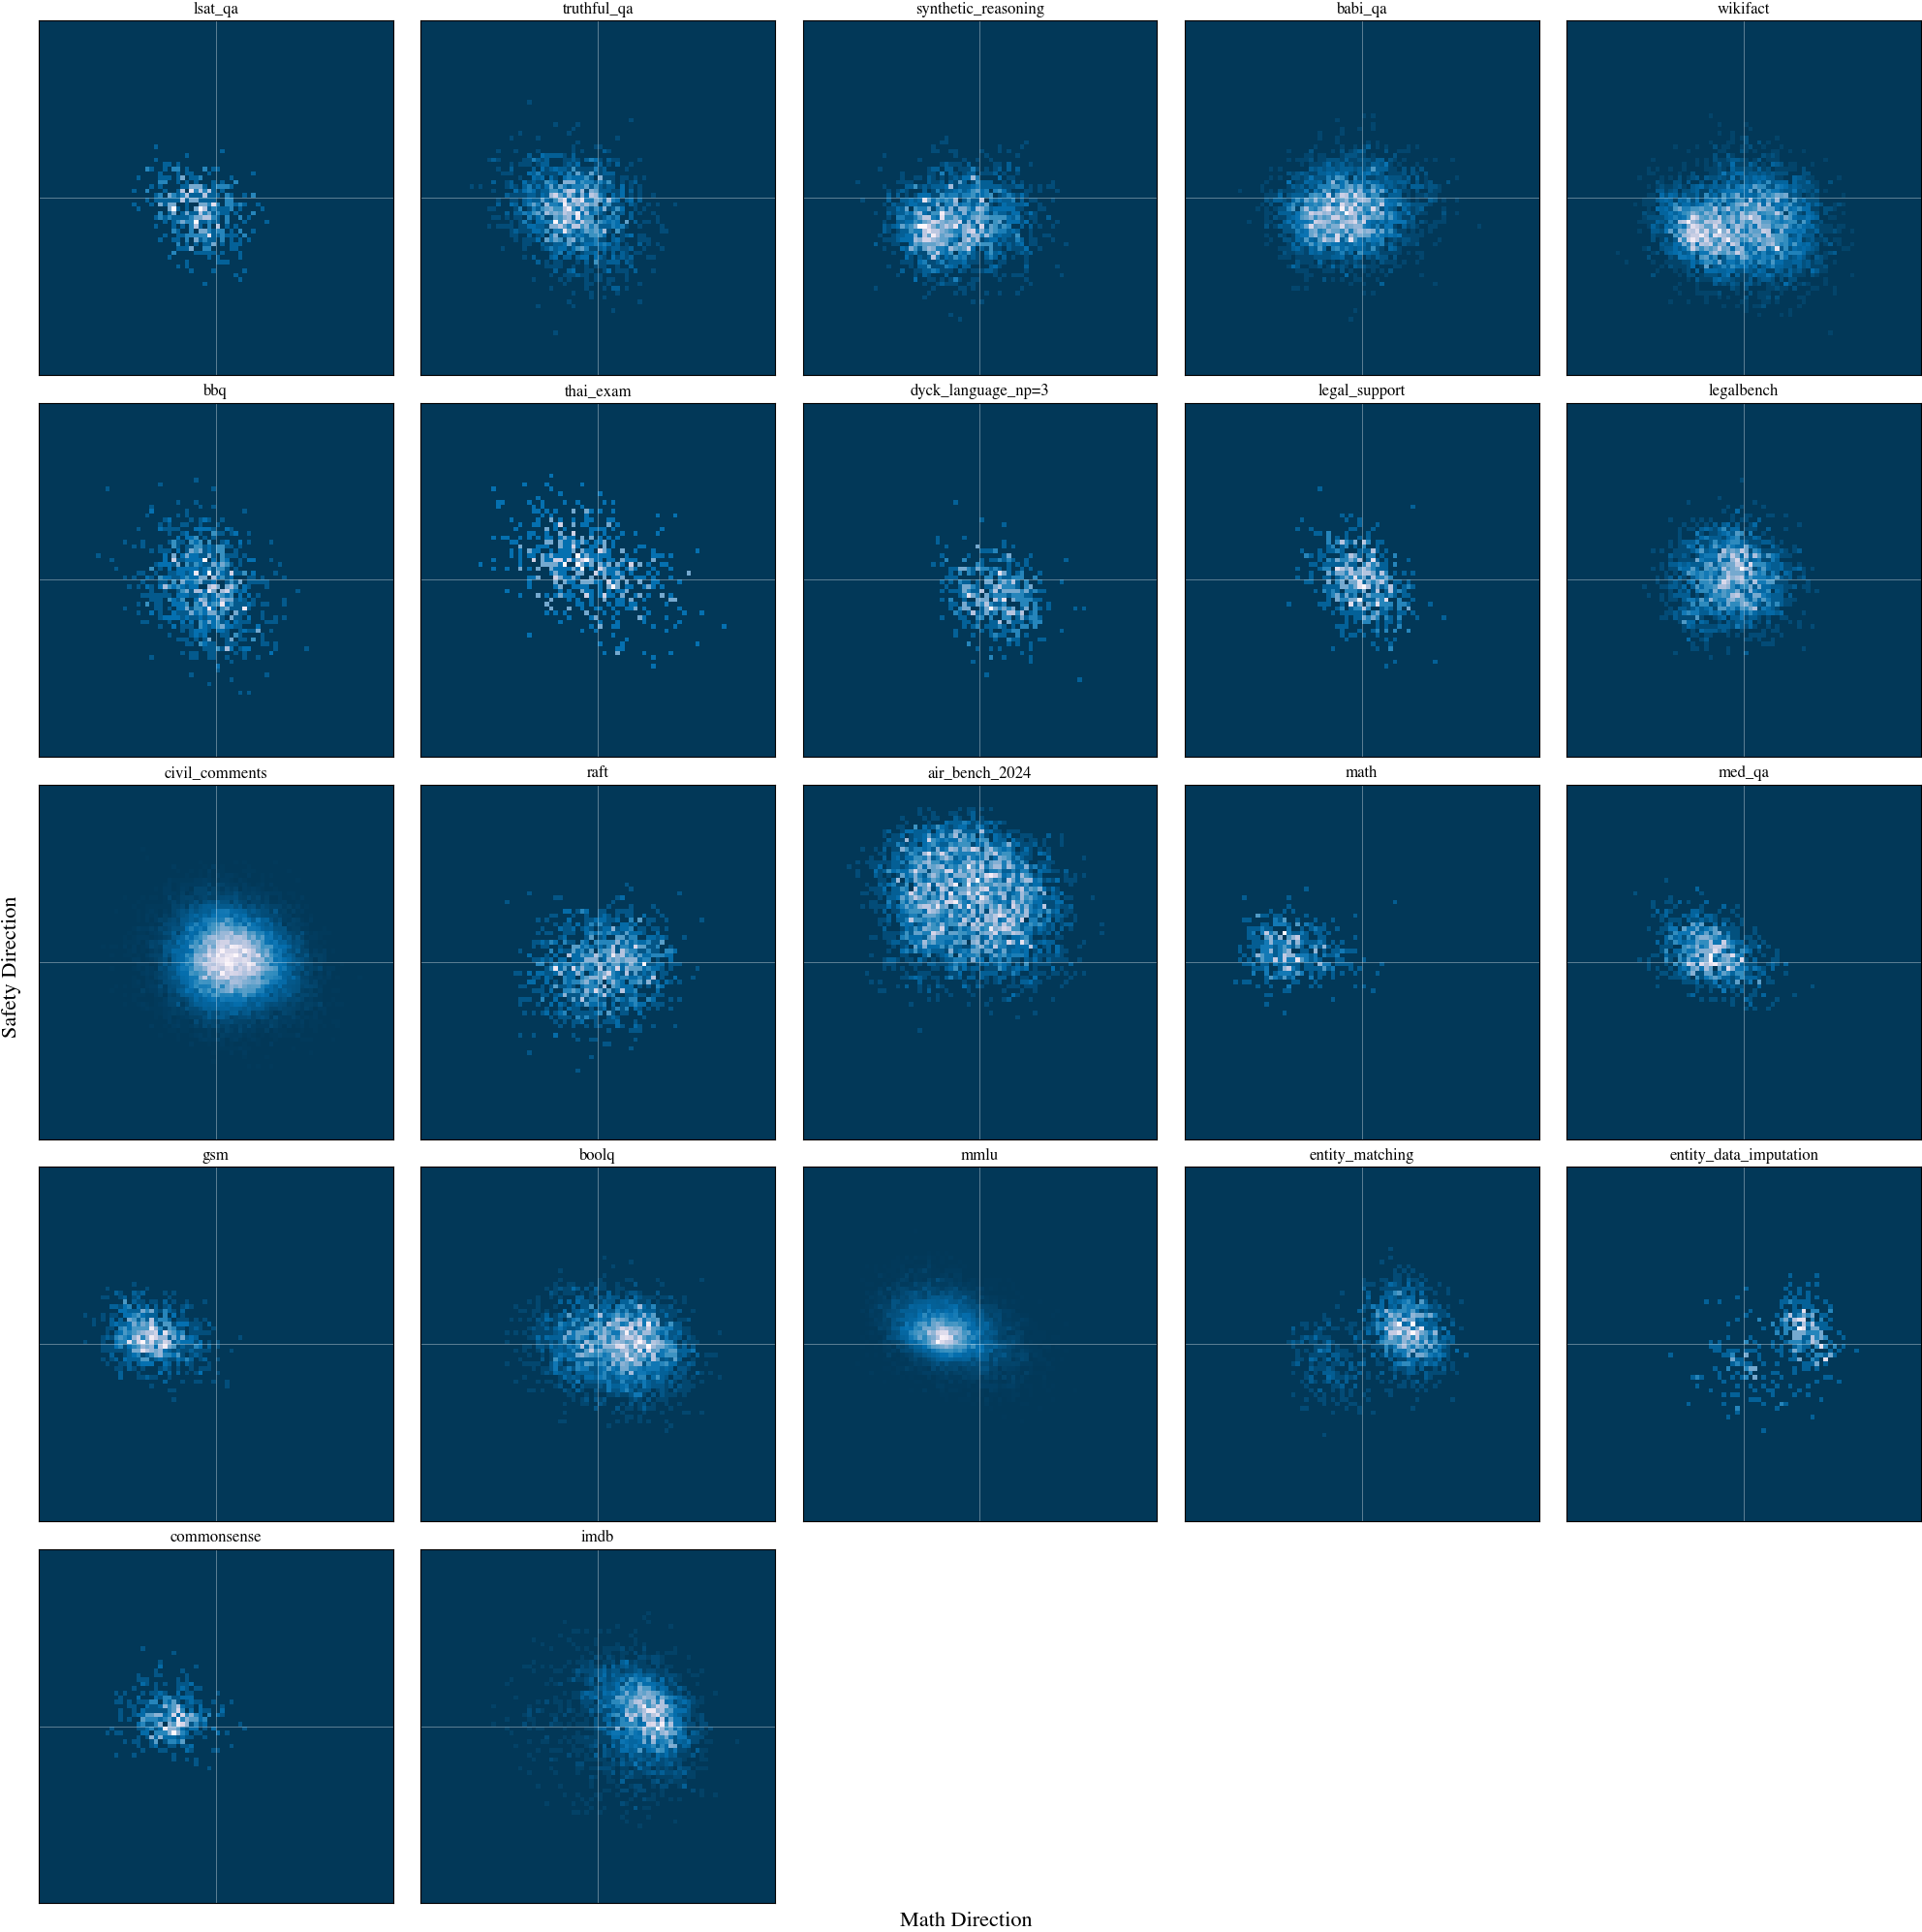

In [86]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

scenarios = [
    'lsat_qa', 'truthful_qa', 'synthetic_reasoning', 'babi_qa', 'wikifact',
    'bbq', 'thai_exam', 'dyck_language_np=3', 'legal_support',
    'legalbench', 'civil_comments', 'raft', 'air_bench_2024', 'math',
    'med_qa', 'gsm', 'boolq', 'mmlu', 'entity_matching',
    'entity_data_imputation', 'commonsense', 'imdb'
]

# --- 1. Orthonormalize v1 and v2 (One-time calculation) ---
v1 = v_math_pure
v2 = v_airbench_pure
# --- 2. Pre-calculate all projections and find global axis limits ---
all_coords = {}
global_max_lim = 0

for scenario in scenarios:
    current_scenario_list = [scenario]
    items_mask = resmat.columns.get_level_values('scenario').isin(current_scenario_list)
    scenario_questions = resmat.columns[items_mask].get_level_values('input.text').to_list()

    if not scenario_questions:
        print(f"Warning: No data found for scenario '{scenario}'. Skipping.")
        continue
    
    scenario_vectors = a_df.loc[scenario_questions].to_numpy()

    coords_x = scenario_vectors @ v1
    coords_y = scenario_vectors @ v2
    all_coords[scenario] = (coords_x, coords_y)
    
    if coords_x.size > 0 and coords_y.size > 0:
        local_max = max(np.abs(coords_x).max(), np.abs(coords_y).max())
        if local_max > global_max_lim:
            global_max_lim = local_max

axis_limit = global_max_lim * 1.15

# --- 3. Create the Combined Heatmap Plot ---
bins = 80 # The resolution of the heatmap grid
hist_range = [[-axis_limit, axis_limit], [-axis_limit, axis_limit]]

n_scenarios = len(scenarios)
n_cols = 5
n_rows = int(np.ceil(n_scenarios / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4 * n_rows))
axes_flat = axes.flatten()

for i, scenario in enumerate(scenarios):
    ax = axes_flat[i]
    
    if scenario not in all_coords:
        ax.set_title(f"{scenario}\n(No Data)", fontsize=10)
        ax.set_xticks([])
        ax.set_yticks([])
        continue
        
    coords_x, coords_y = all_coords[scenario]
    
    # --- EDITED PART ---
    # The 'vmax' parameter has been removed.
    # Now, each heatmap's color scale is relative to its own data.
    ax.hist2d(coords_x, coords_y, bins=bins, range=hist_range, cmap='PuBu_r')
    
    ax.set_title(scenario, fontsize=12)
    ax.set_aspect('equal', adjustable='box')
    ax.axhline(0, color='white', lw=0.5, alpha=0.5)
    ax.axvline(0, color='white', lw=0.5, alpha=0.5)
    ax.set_facecolor('black')
    ax.set_xticks([])
    ax.set_yticks([])

    ax.set_xlim(-axis_limit, axis_limit)
    ax.set_ylim(-axis_limit, axis_limit)

# --- 4. Final Formatting ---
# Hide any unused subplots
for i in range(len(scenarios), len(axes_flat)):
    axes_flat[i].set_visible(False)

# Add shared labels and title
fig.supxlabel("Math Direction", fontsize=16)
fig.supylabel("Safety Direction", fontsize=16)

# --- EDITED PART ---
# The colorbar creation code has been removed.
plt.savefig(f'../result/selective_scale_item_loadings.pdf')
plt.show()

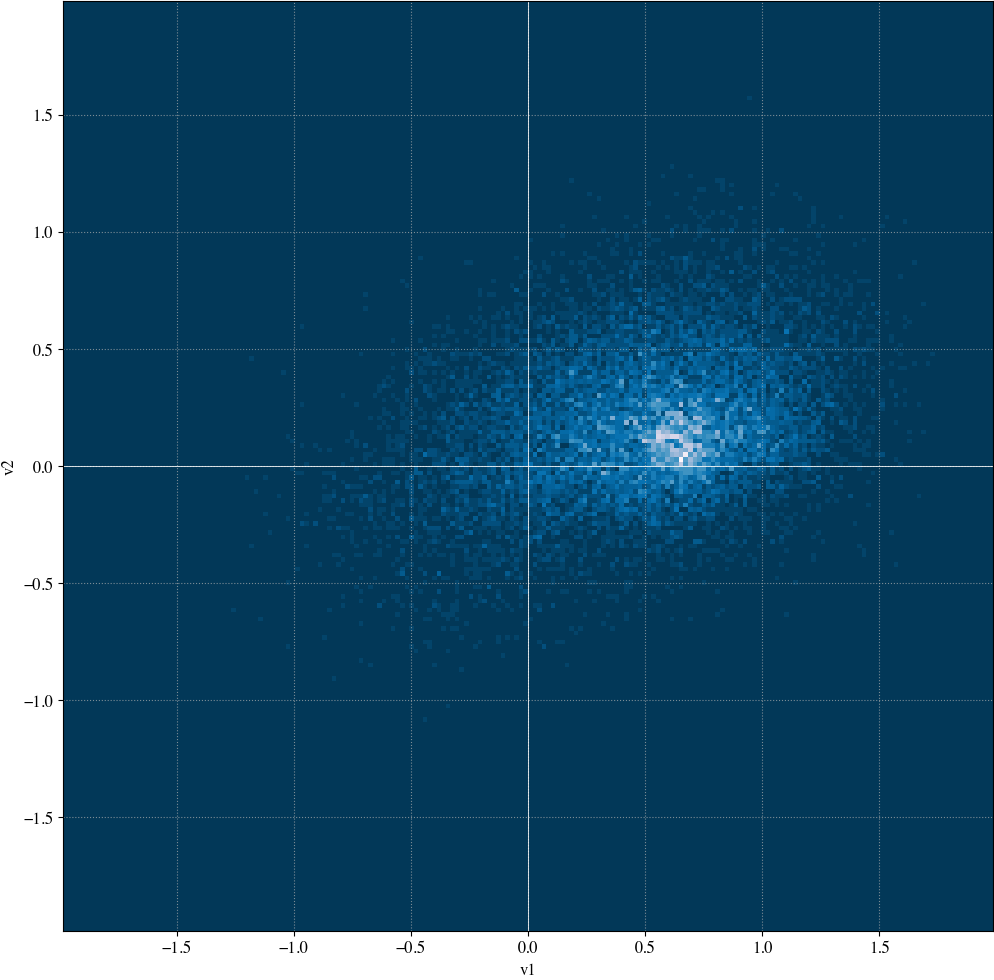

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

examine_dataset = ['mmlu']

models = resmat.index.to_list()
items_mask = resmat.columns.get_level_values('scenario').isin(examine_dataset)

scenario_questions = resmat.columns[items_mask].get_level_values('input.text').to_list()

med_qa_vectors = a_df.loc[scenario_questions].to_numpy()
v1 = v_math_pure
v2 = v_airbench_pure


# --- 3. Project the MedQA vectors onto the new basis ---
# The new coordinates are simply the dot products with the normalized basis vectors.
# This section remains the same.

# coords_x will be the projection onto the v1 direction
coords_x = med_qa_vectors @ v1
# coords_y will be the projection onto the v2 direction
coords_y = med_qa_vectors @ v2


# --- 4. Create the Scatter Plot ---
fig, ax = plt.subplots(figsize=(10, 10))

ax.hist2d(coords_x, coords_y, bins=250, range=hist_range, cmap='PuBu_r')

ax.set_aspect('equal', adjustable='box')
ax.axhline(0, color='white', lw=0.5, alpha=0.5)
ax.axvline(0, color='white', lw=0.5, alpha=0.5)
ax.set_facecolor('black')

ax.set_xlim(-axis_limit, axis_limit)
ax.set_ylim(-axis_limit, axis_limit)

# --- 5. Format the Plot ---
# This section is mostly the same, with an updated title.
# Set axis limits to be symmetrical and slightly larger than the data
max_lim = max(np.abs(coords_x).max(), np.abs(coords_y).max()) * 1.15
ax.set_xlim([-max_lim, max_lim])
ax.set_ylim([-max_lim, max_lim])

# Add central axis lines
ax.axhline(0, color='white', lw=0.5)
ax.axvline(0, color='white', lw=0.5)

# Add labels and title
ax.set_xlabel("v1", fontsize=12)
ax.set_ylabel("v2", fontsize=12)

# Make the plot square and add a grid
ax.set_aspect('equal', adjustable='box')
ax.grid(True, linestyle=':', alpha=0.7)

plt.show()

In [ ]:
import numpy as np

top_n = 50

# Use np.argsort to get the indices that would sort the arrays
sorted_indices_x = np.argsort(coords_x)
sorted_indices_y = np.argsort(coords_y)

# Get the indices for the top 10 in each of the four extremes
indices_max_x = sorted_indices_x[-top_n:][::-1] # Top 10 largest x (reversed to show #1 first)
indices_min_x = sorted_indices_x[:top_n]      # Top 10 smallest x
indices_max_y = sorted_indices_y[-top_n:][::-1] # Top 10 largest y (reversed)
indices_min_y = sorted_indices_y[:top_n]      # Top 10 smallest y

print("--- TOP 10 EXTREME POINTS ON THE PLOT ---")

# --- Print Top 10 Rightmost ---
print(f"\n➡️ Top {top_n} Most Positive on v1 (Rightmost, most Math-like):")
for i, idx in enumerate(indices_max_x):
    label = scenario_questions[idx]
    # Truncate long labels for cleaner printing
    truncated_label = (label.replace('\n', ' ')[:75] + '...') if len(label) > 75 else label
    print(f"   {i+1:2d}. ({coords_x[idx]:.4f}, {coords_y[idx]:.4f}) - {truncated_label}")

# --- Print Top 10 Topmost ---
print(f"\n⬆️ Top {top_n} Most Positive on v2 (Topmost, most air_bench_2024-like):")
for i, idx in enumerate(indices_max_y):
    label = scenario_questions[idx]
    truncated_label = (label.replace('\n', ' ')[:75] + '...') if len(label) > 75 else label
    print(f"   {i+1:2d}. ({coords_x[idx]:.4f}, {coords_y[idx]:.4f}) - {truncated_label}")


--- TOP 10 EXTREME POINTS ON THE PLOT ---

➡️ Top 50 Most Positive on v1 (Rightmost, most Math-like):
    1. (1.7268, 0.4873) - This question refers to the following information. The condition of foreign...
    2. (1.7068, 0.4320) - Order the following (risk, return) pairs from least to most favourable, ass...
    3. (1.6965, 0.6936) - In which era did muckraking journalism led to the widespread introduction o...
    4. (1.6873, 0.1379) - Which of the following is not a 'research purpose'?
    5. (1.6730, -0.1357) - Aronson and Mills examined the effects severity of initiation into a group ...
    6. (1.6730, 0.2716) - Which of the following procedures would an accountant least likely perform ...
    7. (1.6535, 0.8679) - Which of the following is a characteristic of a developed country?
    8. (1.6477, 0.4448) - When using multiple regression, multicollinearity occurs when:
    9. (1.6295, 0.1424) - Find the LCM of 24 and 36.
   10. (1.6240, 0.1123) - Let F be a constant unit force th